<a href="https://colab.research.google.com/github/Ankits112/Bank-Loan-Report-Analysis/blob/main/Swiggy_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Swiggy Sales Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

##Importing Data

In [2]:
df = pd.read_excel('/content/swiggy_data.xlsx')

In [3]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [4]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


In [5]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


In [6]:
print(df.dtypes)

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object


##Meta Data

In [7]:
print('No. of Rows :', df.shape[0])

No. of Rows : 197430


In [8]:
print('No. of columns: ', df.shape[1])

No. of columns:  10


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


#Data Types

In [10]:
print(df.dtypes)

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object


##KPI's

##Total Sales - Overall Revenue Generated from food orders

In [11]:
total_revenue = df['Price (INR)'].sum() / 10000000
print(f'Total Revenue : ₹{total_revenue:.2f} Cr.')

Total Revenue : ₹5.30 Cr.


##Average Rating - Customer Satisfaction level across all restaurants

In [12]:
overall_restaurant_avg_rating = df['Rating'].mean()
print(f'Overall Restaurants Average Rating :{overall_restaurant_avg_rating:.1f}')

Overall Restaurants Average Rating :4.3


##Average Order Value - Revenue per order

In [13]:
avg_order_value = df['Price (INR)'].mean()
print(f'Average Order Value : ₹{avg_order_value:.2f}')

Average Order Value : ₹268.51


#Rating Count - Total no. of customer reviews

In [14]:
total_number_of_ratings = df['Rating Count'].sum()
print('Total number of Ratings :',total_number_of_ratings)

Total number of Ratings : 5591574


##Total number of food order received

In [15]:
total_orders = len(df)
print('Total no. of orders :', total_orders)

Total no. of orders : 197430


#Trend Analysis

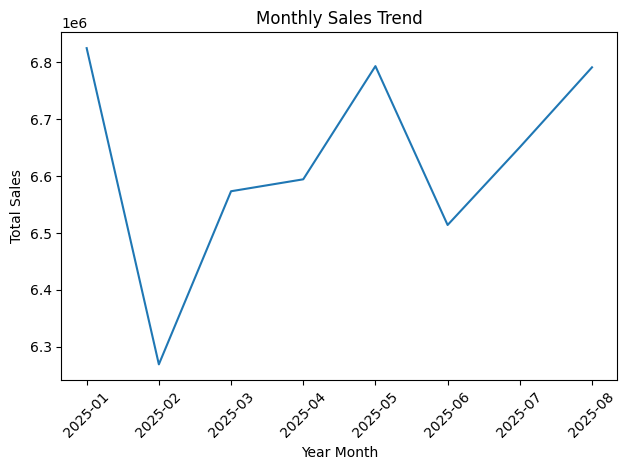

In [16]:
df['Year Month'] = df['Order Date'].dt.to_period('M').astype(str)

monthly_sales_data = df.groupby('Year Month')['Price (INR)'].sum().reset_index()

plt.figure()
plt.plot(monthly_sales_data['Year Month'], monthly_sales_data['Price (INR)'])
plt.xlabel('Year Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Daily Sales Trend

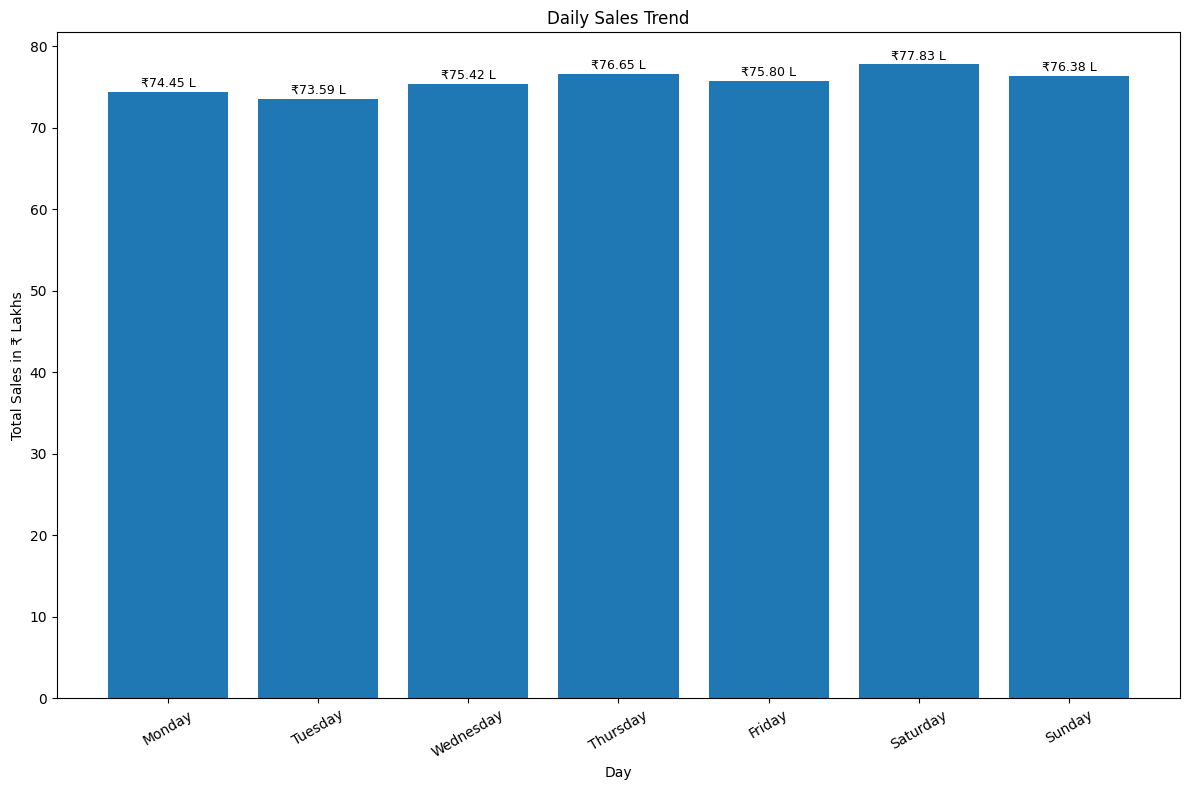

In [17]:
df['day_name'] = df['Order Date'].dt.day_name()

daily_revenue = (
    df.groupby('day_name')['Price (INR)']
    .sum()
    .div(100000)
    .reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday' , 'Friday', 'Saturday', 'Sunday'])
)

plt.figure(figsize=(12,8))
bars = plt.bar(daily_revenue.index, daily_revenue.values)

for bar in bars:
  height = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'₹{height:.2f} L', ha='center', va='center', fontsize=9, color='black')

plt.xlabel('Day')
plt.xticks(rotation = 30)
plt.ylabel('Total Sales in ₹ Lakhs')
plt.title('Daily Sales Trend')
plt.tight_layout()
plt.show()

##Total Sales by Food Type

In [18]:
from pandas._libs.tslibs.offsets import roll_qtrday
non_veg_keywords = ['chicken','fish','egg','anda','kebab','kabab','non-veg', 'non veg', 'prawn', 'mutton', 'lamb']

df['food_type'] = np.where(df['Dish Name'].str.lower().str.contains('|'.join(non_veg_keywords)),'non-veg','veg')

revenue_by_food_type = (
    df.groupby('food_type')['Price (INR)']
    .sum()
    .div(100000)
    .reset_index()
)

fig = px.pie(
    revenue_by_food_type,
    values ='Price (INR)',
    names = 'food_type',
    hole = 0.5,
    title = 'Total Sales by Food Type'
)

fig.update_traces(textinfo='percent+label', pull=[0.05,0])
fig.update_layout(
    height=500,
    margin=dict(t=60, b=40, l=40, r=40)
)

fig.show()

##Total Sales by State

In [19]:
from matplotlib.axis import YAxis
revenue_by_state = (
    df.groupby('State')["Price (INR)"].sum()
    .sort_values(ascending =False)
)
fig = px.bar(
    revenue_by_state,
    x=revenue_by_state.values,
    y=revenue_by_state.index,
    labels = {'x':'Total Sales in ₹'},
    orientation='h',
    color=revenue_by_state.values,
    color_continuous_scale='Viridis',
    title='Total Sales by State'
)
fig.update_layout(height=600, yaxis=dict(autorange='reversed'))
fig.show()

##Quarterly Performance Summary

In [20]:
df['quarter'] = df['Order Date'].dt.to_period('Q').astype(str)
quarterly_summary = (
    df.groupby('quarter', as_index = False)
    .agg(
        Total_Sales = ('Price (INR)','sum'),
        Avg_ratings = ('Rating', 'mean'),
        Total_orders = ('Order Date','count')
    )
    .sort_values('quarter')
)

quarterly_summary['Total_Sales'] = quarterly_summary['Total_Sales'].round(0)
quarterly_summary['Avg_ratings'] = quarterly_summary['Avg_ratings'].round(2)

quarterly_summary

,quarter,Total_Sales,Avg_ratings,Total_orders
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


##Top 5 cities by sales

In [21]:
top_5_cities = (
    df.groupby('City')['Price (INR)']
    .sum()
    .nlargest(5)
    .reset_index()
)

fig = px.bar(
    top_5_cities,
    x='City',
    y='Price (INR)',
    labels = {'Price (INR)': 'Total Sales in ₹'},
    title='Top 5 cities by sales',
    color_discrete_sequence=['lightcoral']
)

fig.show()

##Weekly Trend Sales

In [22]:
df['week_of_month'] = df['Order Date'].dt.day // 7 + 1

weekly_revenue = (
    df.groupby('week_of_month')['Price (INR)'].sum()
)

fig = px.bar(
    weekly_revenue,
    x=weekly_revenue.index,
    y='Price (INR)',
    labels={'Price (INR)':'Total Sales in ₹'},
    title = 'Weekly Sales Trend',
    color_discrete_sequence=['lightcoral']
)

fig.show()